# Project idea
Develop a system that takes a decent-sized CSV with class imbalance (~8-10k rows) and returns high-quality synthetic data to address that imbalance while preserving realistic data behavior.

## Core changes
- Move to a hosted LLM API service (not small local models).
- Use full-input/full-output flow: entire dataset context goes in, augmented dataset comes out.

## Example use case
User data input:
```
car_brand,car_type,year,car_price
Toyota,sedan,2004,2500
Nissan,hatchback,2010,4300
Honda,suv,2007,5000
```
User instructions:
```
Create 50 more examples of this car survey, from Blacktown, NSW, Australia. Minimize outliers while maintaining realism.
```
Expected patterns in output:
- Contains a diverse number of car brands found in NSW, Australia.
- Contains correct car types and brands (no hallucination of unrelated entities).
- Contains a distribution of years and prices centered around 2000s and early 2010s, with lower-end pricing.
- Shows reasonable relationships between price and year, and price and car type.

## Generation pipeline
1. Input full source CSV and augmentation instruction.
2. Ask the LLM API to infer dataset structure, constraints, and class-level patterns.
3. Generate additional rows for the underrepresented class(es).
4. Return a parseable augmented CSV with schema preserved.

## Evaluation setup (proposed)
1. Find a dataset with ~5-10k rows, preferably initially balanced.
Proposed dataset: `https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset`
2. Filter to around 7 columns to keep the task controlled.
3. Use stratified sampling to preserve overall distribution.
4. Remove ~30% of one class to simulate imbalance.
5. Run the imbalanced data through the augmentation model.

## Metrics
- Formatting: CSV parseability, schema adherence, and data type validity.
- Overall distribution shift: how much post-augmentation distributions differ from the original balanced baseline.
- Correlation fidelity: whether variable relationships are preserved, and how correlation matrices differ from the original dataset.
- Semantic accuracy: how well generated rows reflect inferred dataset characteristics and real-world plausibility.

# 0: Data and libraries

In [1]:
import numpy as np
import pandas as pd
import groq
import matplotlib.pyplot as plt
import seaborn as sns
import os
import dotenv

dotenv.load_dotenv()
df = pd.read_csv("data/UCI_Credit_Card.csv")
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


# 1: Transforming and cleaning data
Data used is from `https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset`, containing the rows of:

```
ID: ID of each client
LIMIT_BAL: Amount of given credit in NT dollars (includes individual and family/supplementary credit)
SEX: Gender (1=male, 2=female)
EDUCATION: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)
MARRIAGE: Marital status (1=married, 2=single, 3=others)
AGE: Age in years
PAY_0: Repayment status in September, 2005 (-1=pay duly, 1=payment delay for one month, 2=payment delay for two months, … 8=payment delay for eight months, 9=payment delay for nine months and above)
PAY_2: Repayment status in August, 2005 (scale same as above)
PAY_3: Repayment status in July, 2005 (scale same as above)
PAY_4: Repayment status in June, 2005 (scale same as above)
PAY_5: Repayment status in May, 2005 (scale same as above)
PAY_6: Repayment status in April, 2005 (scale same as above)
BILL_AMT1: Amount of bill statement in September, 2005 (NT dollar)
BILL_AMT2: Amount of bill statement in August, 2005 (NT dollar)
BILL_AMT3: Amount of bill statement in July, 2005 (NT dollar)
BILL_AMT4: Amount of bill statement in June, 2005 (NT dollar)
BILL_AMT5: Amount of bill statement in May, 2005 (NT dollar)
BILL_AMT6: Amount of bill statement in April, 2005 (NT dollar)
PAY_AMT1: Amount of previous payment in September, 2005 (NT dollar)
PAY_AMT2: Amount of previous payment in August, 2005 (NT dollar)
PAY_AMT3: Amount of previous payment in July, 2005 (NT dollar)
PAY_AMT4: Amount of previous payment in June, 2005 (NT dollar)
PAY_AMT5: Amount of previous payment in May, 2005 (NT dollar)
PAY_AMT6: Amount of previous payment in April, 2005 (NT dollar)
default.payment.next.month: Default payment (1=yes, 0=no)
```
Final rows include:
```
LIMIT_BALL: number
SEX: 'male' or 'female'
EDUCATION: 'graduate', 'university', 'high school', 'others', drop unknown classes
MARRIAGE: 0, 1
AGE: number
PAYMENT_BALANCE_*: PAY_AMT* - BILL_AMT*
DEFAULT: 0, 1
SUBURB: Random of 20 suburbs around Sydney, testing the model's ability to pick up on context.
```


In [2]:
# Build a cleaned version of the dataset based on the rules above.
working = df.copy()

# Standardize target column name.
working = working.rename(columns={"default.payment.next.month": "DEFAULT"})

# Keep only valid classes for EDUCATION and MARRIAGE.
working = working[working["EDUCATION"].isin([1, 2, 3, 4])]
working = working[working["MARRIAGE"].isin([1, 2])]

# Map coded values to readable categories.
working["SEX"] = working["SEX"].map({1: "male", 2: "female"})
working["EDUCATION"] = working["EDUCATION"].map({
    1: "graduate",
    2: "university",
    3: "high school",
    4: "others"
})

# Keep MARRIAGE as binary (married=1, single=0).
working["MARRIAGE"] = working["MARRIAGE"].map({1: 1, 2: 0})

# Add random suburb values from the provided list.
suburbs = [
    "Auburn",
    "Berala",
    "Homebush",
    "Homebush West",
    "Strathfield",
    "Flemington",
    "Rookwood",
    "Chullora",
    "Sydney Olympic Park",
    "North Strathfield",
    "Strathfield South",
    "Birrong",
    "Sefton",
    "South Granville",
    "Granville",
]
rng = np.random.default_rng(42)
working["SUBURB"] = rng.choice(suburbs, size=len(working), replace=True)

# Create PAYMENT_BALANCE_i = BILL_AMTi - PAY_AMTi for i in 1..6.
for i in range(1, 7):
    working[f"PAYMENT_BALANCE_{i}"] = working[f"BILL_AMT{i}"] - working[f"PAY_AMT{i}"]

# Select final columns for modeling/augmentation.
final_columns = [
    "LIMIT_BAL",
    "SUBURB",
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "AGE",
    "PAYMENT_BALANCE_1",
    "PAYMENT_BALANCE_2",
    "PAYMENT_BALANCE_3",
    "PAYMENT_BALANCE_4",
    "PAYMENT_BALANCE_5",
    "PAYMENT_BALANCE_6",
    "DEFAULT",
]

clean_df = working[final_columns].dropna().reset_index(drop=True)

# Force all numeric columns to integer dtype.
numeric_cols = clean_df.select_dtypes(include=[np.number]).columns
clean_df[numeric_cols] = clean_df[numeric_cols].round().astype(int)

clean_df.head()
clean_df.shape

clean_df.head(10)

,LIMIT_BAL,SUBURB,SEX,EDUCATION,MARRIAGE,AGE,PAYMENT_BALANCE_1,PAYMENT_BALANCE_2,PAYMENT_BALANCE_3,PAYMENT_BALANCE_4,PAYMENT_BALANCE_5,PAYMENT_BALANCE_6,DEFAULT
0,20000,Berala,female,university,1,24,3913,2413,689,0,0,0,1
1,120000,Birrong,female,university,0,26,2682,725,1682,2272,3455,1261,1
2,90000,North Strathfield,female,university,0,34,27721,12527,12559,13331,13948,10549,0
3,50000,Rookwood,female,university,1,37,44990,46214,48091,27214,27890,28547,0
4,50000,Rookwood,male,university,1,57,6617,-31011,25835,11940,18457,18452,0
5,50000,Sefton,male,graduate,0,37,61900,55254,56951,18394,18619,19224,0
6,500000,Berala,male,graduate,0,29,312965,372023,407007,522414,469253,460174,0
7,100000,Strathfield South,female,university,0,23,11496,-221,601,-360,-1846,-975,0
8,140000,Homebush West,female,high school,1,28,7956,14096,11676,11211,10793,2719,0
9,20000,Berala,male,high school,0,35,0,0,0,-13007,11885,13912,0


# 2: Visualizing and analyzing trends in original dataset

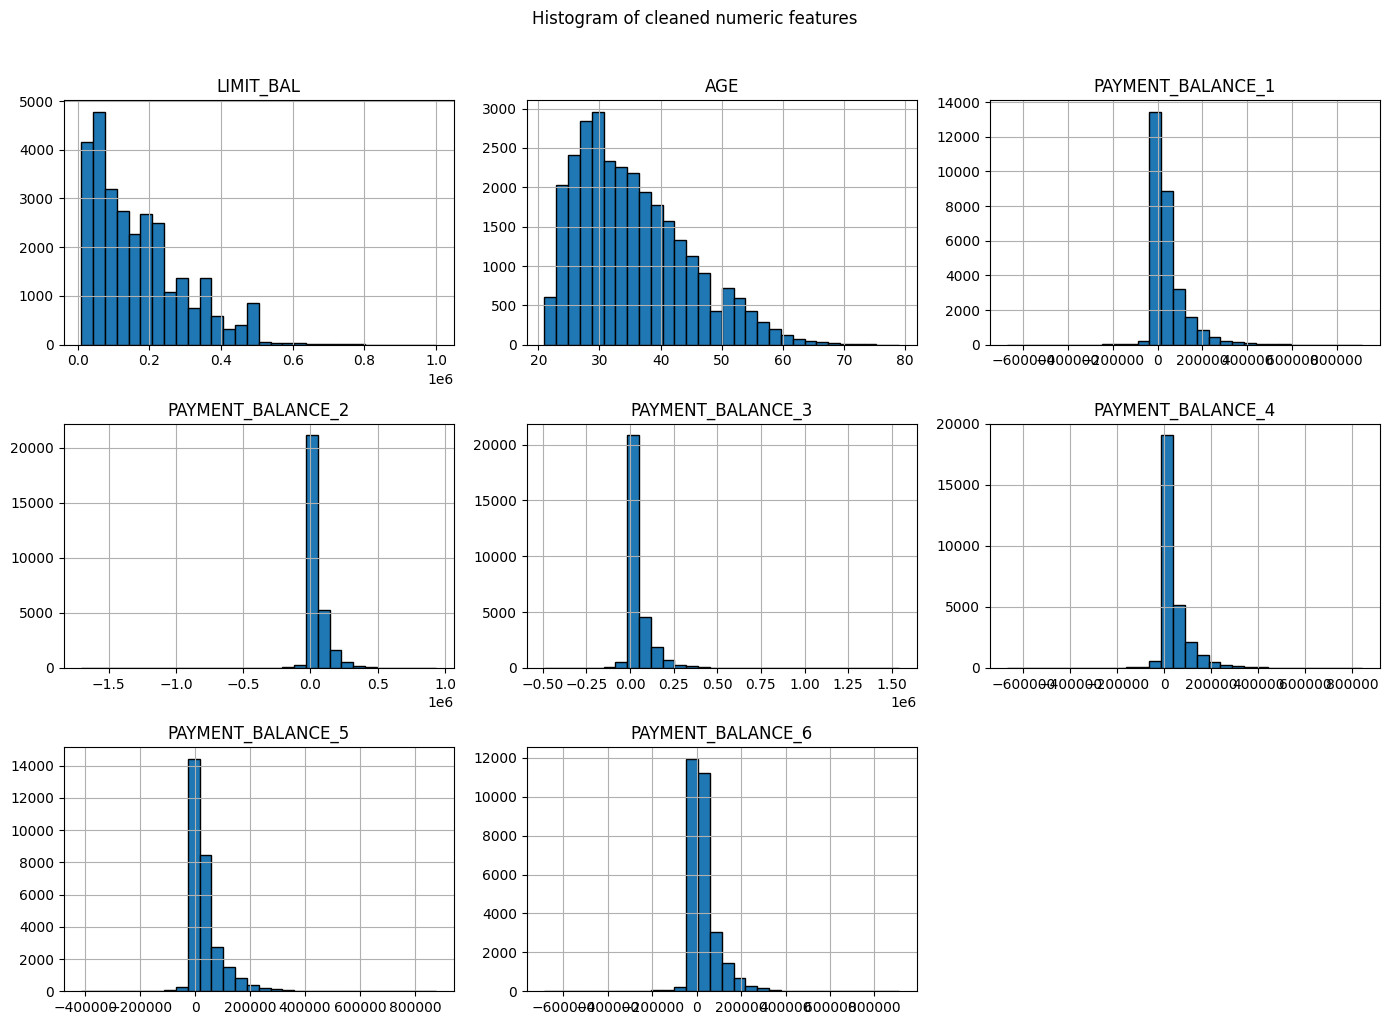

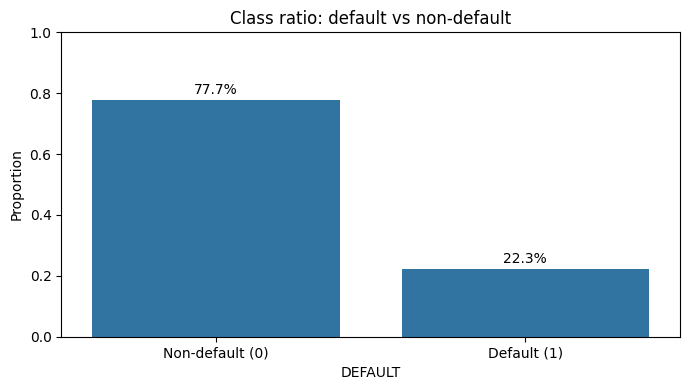

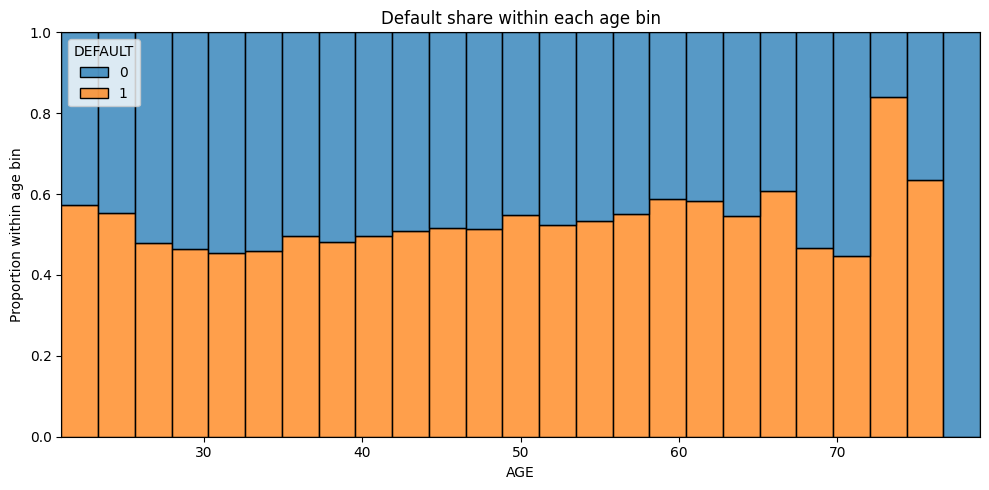

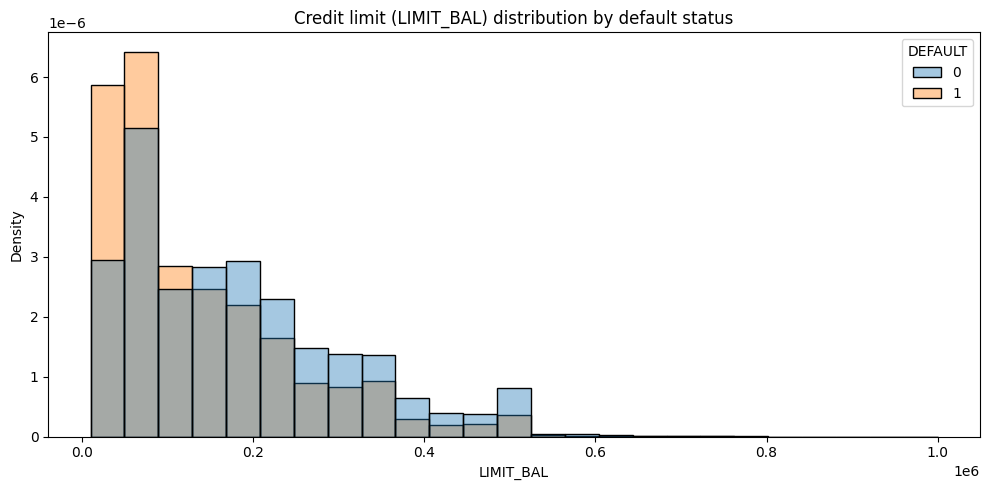

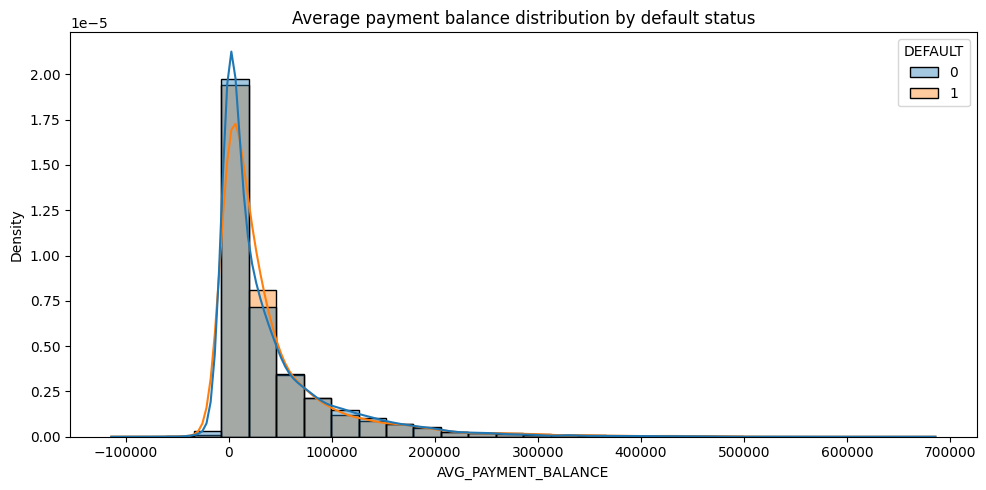

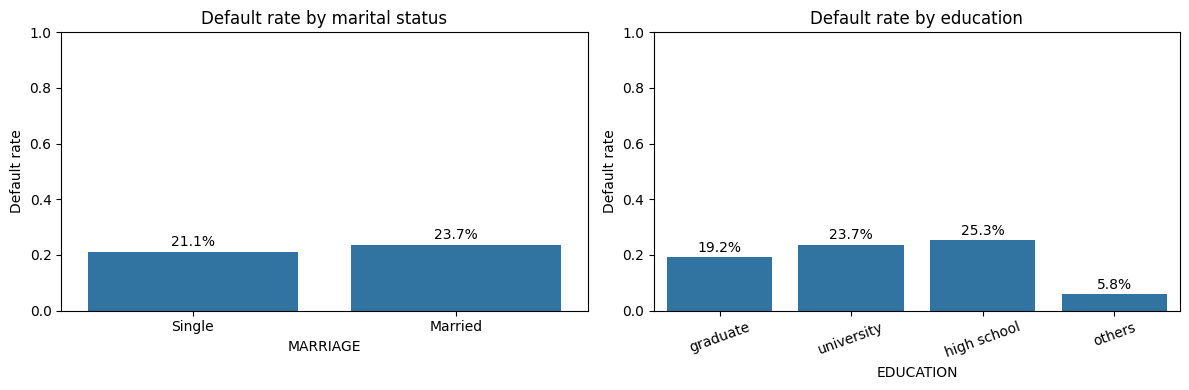

In [4]:
def draw_analytics(df):
	# Draw histogram of key numeric columns in the cleaned dataset.
	numeric_cols = ["LIMIT_BAL", "AGE"] + [f"PAYMENT_BALANCE_{i}" for i in range(1, 7)]
	df[numeric_cols].hist(figsize=(14, 10), bins=30, edgecolor="black")
	plt.suptitle("Histogram of cleaned numeric features", y=1.02)
	plt.tight_layout()
	plt.show()

	# Show overall class ratio (DEFAULT vs NON-DEFAULT) as percentages.
	ratio = df["DEFAULT"].value_counts(normalize=True).sort_index()
	ratio.index = ratio.index.map({0: "Non-default (0)", 1: "Default (1)"})

	plt.figure(figsize=(7, 4))
	ax = sns.barplot(x=ratio.index, y=ratio.values)
	plt.title("Class ratio: default vs non-default")
	plt.ylabel("Proportion")
	plt.ylim(0, 1)
	for i, v in enumerate(ratio.values):
		ax.text(i, v + 0.02, f"{v:.1%}", ha="center")
	plt.tight_layout()
	plt.show()

	# Better ratio view inside histogram: each age bin normalized to 100%.
	plt.figure(figsize=(10, 5))
	sns.histplot(
		data=df,
		x="AGE",
		hue="DEFAULT",
		bins=25,
		multiple="fill",
		stat="proportion",
		common_norm=False
	)
	plt.title("Default share within each age bin")
	plt.ylabel("Proportion within age bin")
	plt.tight_layout()
	plt.show()

	# Compare LIMIT_BAL distribution between default and non-default groups using histogram bars.
	plt.figure(figsize=(10, 5))
	sns.histplot(
		data=df,
		x="LIMIT_BAL",
		hue="DEFAULT",
		bins=25,
		stat="density",
		common_norm=False,
		multiple="layer",
		alpha=0.4,
		element="bars"
	)
	plt.title("Credit limit (LIMIT_BAL) distribution by default status")
	plt.xlabel("LIMIT_BAL")
	plt.ylabel("Density")
	plt.tight_layout()
	plt.show()

	# Compute average payment balance in a temporary frame (do not mutate input df).
	balance_cols = [f"PAYMENT_BALANCE_{i}" for i in range(1, 7)]
	plot_df = pd.DataFrame({
		"AVG_PAYMENT_BALANCE": df[balance_cols].mean(axis=1),
		"DEFAULT": df["DEFAULT"].values
	})

	# Histogram of average payment balance split by default status.
	plt.figure(figsize=(10, 5))
	sns.histplot(
		data=plot_df,
		x="AVG_PAYMENT_BALANCE",
		hue="DEFAULT",
		bins=30,
		stat="density",
		common_norm=False,
		multiple="layer",
		alpha=0.4,
		kde=True
	)
	plt.title("Average payment balance distribution by default status")
	plt.xlabel("AVG_PAYMENT_BALANCE")
	plt.ylabel("Density")
	plt.tight_layout()
	plt.show()

	# Marriage and education versus default rate.
	marriage_rate = df.groupby("MARRIAGE")["DEFAULT"].mean().reset_index()
	marriage_rate["MARRIAGE_LABEL"] = marriage_rate["MARRIAGE"].map({0: "Single", 1: "Married"})

	education_order = ["graduate", "university", "high school", "others"]
	education_rate = (
		df.groupby("EDUCATION")["DEFAULT"]
		.mean()
		.reindex(education_order)
		.reset_index()
	)

	fig, axes = plt.subplots(1, 2, figsize=(12, 4))

	sns.barplot(data=marriage_rate, x="MARRIAGE_LABEL", y="DEFAULT", ax=axes[0])
	axes[0].set_title("Default rate by marital status")
	axes[0].set_xlabel("MARRIAGE")
	axes[0].set_ylabel("Default rate")
	axes[0].set_ylim(0, 1)
	for i, v in enumerate(marriage_rate["DEFAULT"]):
		axes[0].text(i, v + 0.02, f"{v:.1%}", ha="center")

	sns.barplot(data=education_rate, x="EDUCATION", y="DEFAULT", ax=axes[1])
	axes[1].set_title("Default rate by education")
	axes[1].set_xlabel("EDUCATION")
	axes[1].set_ylabel("Default rate")
	axes[1].set_ylim(0, 1)
	axes[1].tick_params(axis="x", rotation=20)
	for i, v in enumerate(education_rate["DEFAULT"]):
		if pd.notna(v):
			axes[1].text(i, v + 0.02, f"{v:.1%}", ha="center")

	plt.tight_layout()
	plt.show()

draw_analytics(clean_df)

# 4: Rebalance dataset by stratified sampling from non-default group

Original class counts:
DEFAULT
0    22762
1     6521
Name: count, dtype: int64

Balanced class counts:
DEFAULT
0    500
1    500
Name: count, dtype: int64

Distribution check for SEX:
        original_nondefault  sampled_nondefault
SEX                                            
female               0.6136               0.616
male                 0.3864               0.384

Distribution check for EDUCATION:
             original_nondefault  sampled_nondefault
EDUCATION                                           
graduate                  0.3738               0.376
high school               0.1566               0.156
others                    0.0050               0.002
university                0.4647               0.466

Distribution check for MARRIAGE:
          original_nondefault  sampled_nondefault
MARRIAGE                                         
0                      0.5482               0.552
1                      0.4518               0.448


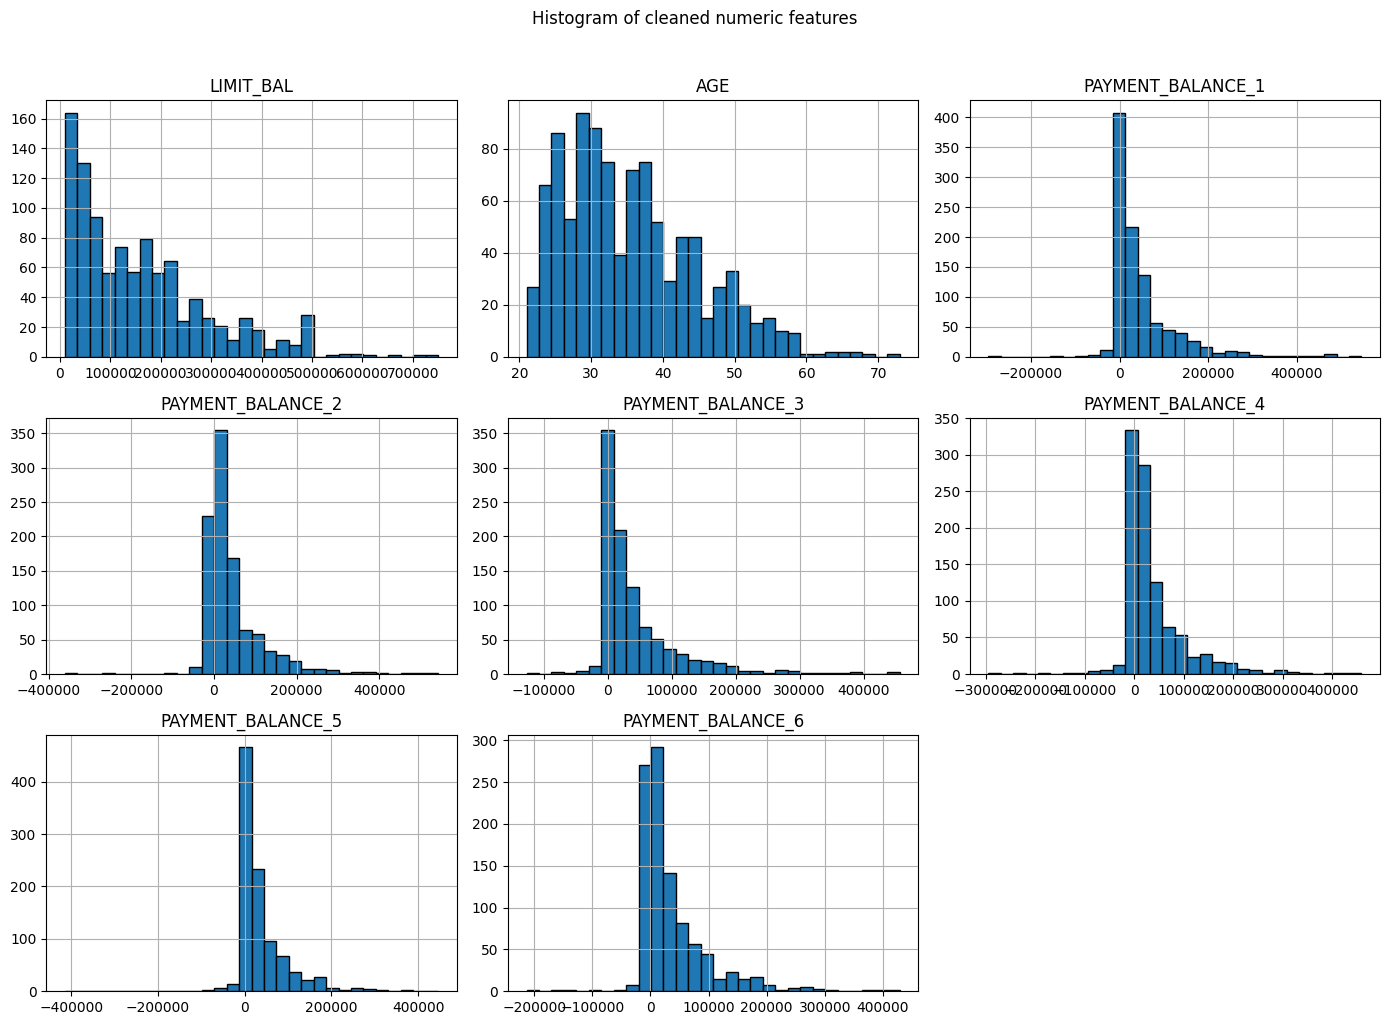

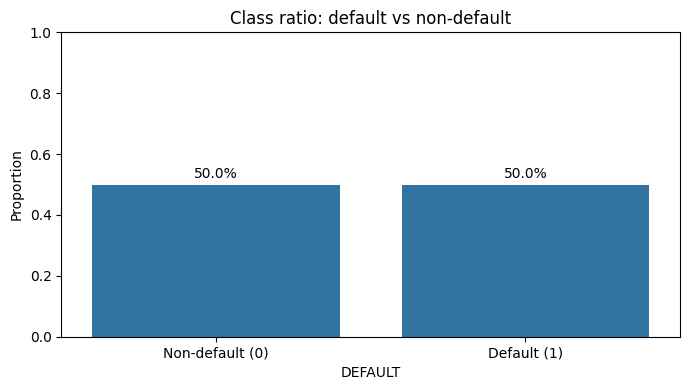

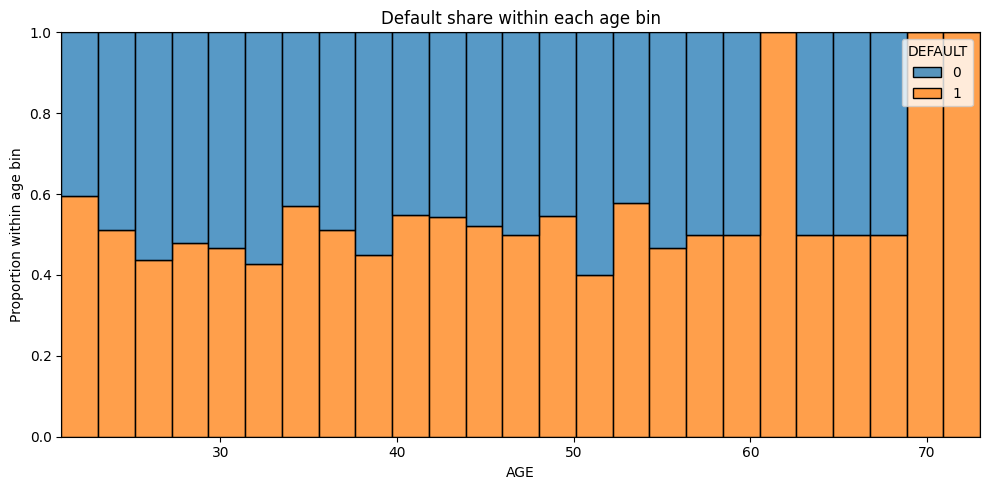

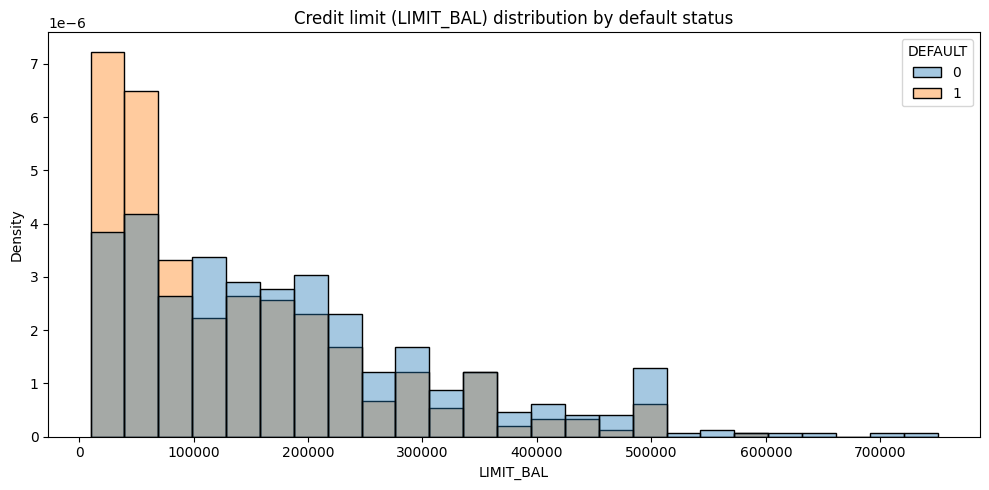

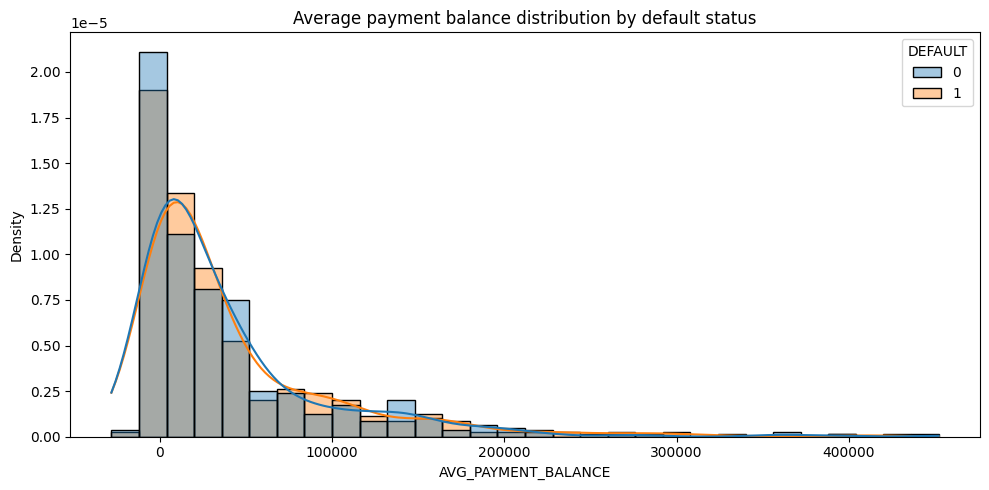

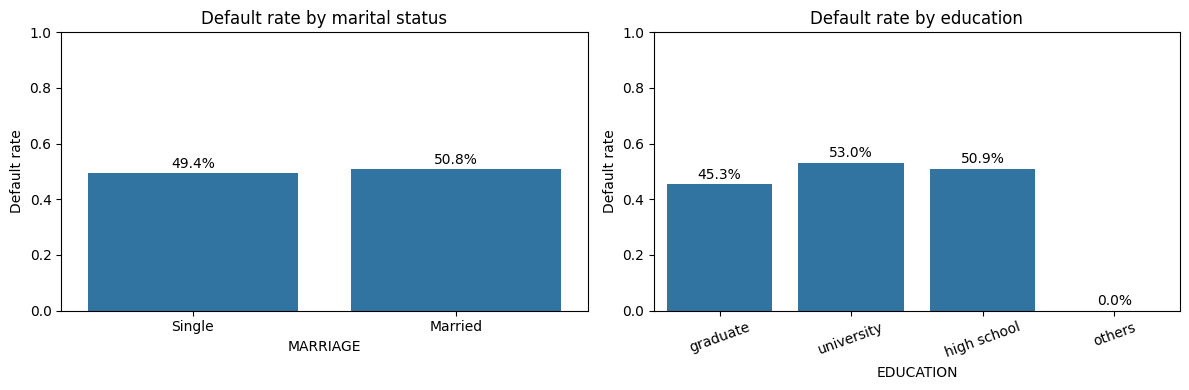

In [9]:
# Rebalance dataset by stratified sampling from the non-default group,
# while sampling both classes to the same target size.
random_state = 42
target_per_class = 500

default_full = clean_df[clean_df["DEFAULT"] == 1].copy()
nondefault_df = clean_df[clean_df["DEFAULT"] == 0].copy()

# Sample DEFAULT class directly to target size (or max available).
n_default = min(target_per_class, len(default_full))
default_df = default_full.sample(n=n_default, random_state=random_state)

# Sample NON-DEFAULT class with stratification to target size (or max available).
target_nondefault_n = min(target_per_class, len(nondefault_df))

nondefault_df["AGE_BIN"] = pd.cut(
    nondefault_df["AGE"],
    bins=[17, 25, 35, 45, 55, 80],
    labels=["18-25", "26-35", "36-45", "46-55", "56+"],
    include_lowest=True
 )
strata_cols = ["SEX", "EDUCATION", "MARRIAGE", "AGE_BIN"]
nondefault_df["STRATA"] = nondefault_df[strata_cols].astype(str).agg("|".join, axis=1)

# Proportional allocation per stratum (largest-remainder adjustment).
strata_counts = nondefault_df["STRATA"].value_counts()
weights = strata_counts / strata_counts.sum()
exact_alloc = weights * target_nondefault_n
alloc = np.floor(exact_alloc).astype(int)

remaining = target_nondefault_n - alloc.sum()
if remaining > 0:
    remainders = (exact_alloc - alloc).sort_values(ascending=False)
    for s in remainders.index[:remaining]:
        alloc[s] += 1

alloc = alloc.clip(lower=0, upper=strata_counts)
deficit = target_nondefault_n - alloc.sum()
if deficit > 0:
    capacity = (strata_counts - alloc).sort_values(ascending=False)
    for s in capacity.index:
        if deficit == 0:
            break
        add = min(deficit, capacity[s])
        alloc[s] += add
        deficit -= add

sampled_parts = []
for s, n in alloc.items():
    if n > 0:
        sampled_parts.append(
            nondefault_df[nondefault_df["STRATA"] == s].sample(n=n, random_state=random_state)
        )

sampled_nondefault_df = pd.concat(sampled_parts, ignore_index=True)
sampled_nondefault_df = sampled_nondefault_df.drop(columns=["AGE_BIN", "STRATA"], errors="ignore")

# Final balanced dataset: target_per_class defaults + target_per_class non-defaults (when available).
balanced_df = pd.concat([default_df, sampled_nondefault_df], ignore_index=True)
balanced_df = balanced_df.sample(frac=1, random_state=random_state).reset_index(drop=True)

print("Original class counts:")
print(clean_df["DEFAULT"].value_counts().sort_index())
print("\nBalanced class counts:")
print(balanced_df["DEFAULT"].value_counts().sort_index())
if n_default < target_per_class or target_nondefault_n < target_per_class:
    print("\nNote: One or both classes had fewer than 5000 rows, so max available rows were used.")

# Quick checks: compare marginal distributions before vs sampled non-default.
for col in ["SEX", "EDUCATION", "MARRIAGE"]:
    original_dist = nondefault_df[col].value_counts(normalize=True).sort_index()
    sampled_dist = sampled_nondefault_df[col].value_counts(normalize=True).sort_index()
    compare = pd.concat([original_dist, sampled_dist], axis=1)
    compare.columns = ["original_nondefault", "sampled_nondefault"]
    print(f"\nDistribution check for {col}:")
    print(compare.fillna(0).round(4))

balanced_df.head()
draw_analytics(balanced_df)

# 5: Defining evaluation metrics
For LLM-generated data to be useful for class-imbalance correction, evaluate it on four dimensions:

1. Formatting and schema validity
- CSV parseability (file can be read without errors).
- Exact schema match (same column names and order as training data).
- Type compatibility (numeric columns remain numeric, categorical columns remain categorical).

2. Class-imbalance objective
- Target class proportion gap: how close generated/augmented data is to desired class ratio.
- Minority class count gain: increase in minority examples after augmentation.
- Balance improvement: reduction in majority/minority ratio gap.

3. Statistical fidelity
- Numeric distribution similarity (mean relative error, KS statistic).
- Categorical distribution similarity (total variation distance).
- Correlation fidelity (difference between real and generated correlation matrices).

4. Data quality and realism
- Null rate and invalid value rate.
- Out-of-range numeric rate (outside real-data min/max).
- Unseen category rate for categorical columns.
- Duplicate rate and novelty rate vs source data.

The code cell below computes a practical subset of these metrics for quick iteration.

In [8]:
def _ks_statistic(x_real, x_synth):
    """Compute two-sample KS statistic without external dependencies."""
    x_real = np.asarray(pd.Series(x_real).dropna(), dtype=float)
    x_synth = np.asarray(pd.Series(x_synth).dropna(), dtype=float)
    if len(x_real) == 0 or len(x_synth) == 0:
        return np.nan
    grid = np.sort(np.unique(np.concatenate([x_real, x_synth])))
    cdf_real = np.searchsorted(np.sort(x_real), grid, side="right") / len(x_real)
    cdf_synth = np.searchsorted(np.sort(x_synth), grid, side="right") / len(x_synth)
    return np.max(np.abs(cdf_real - cdf_synth))


def evaluate_generated_data(real_df, generated_df, target_col="DEFAULT"):
    """Evaluate generated/augmented data quality against a real reference dataset."""
    metrics = {}

    # 1) Schema checks
    real_cols = list(real_df.columns)
    gen_cols = list(generated_df.columns)
    metrics["schema_exact_match"] = int(real_cols == gen_cols)
    metrics["missing_columns_count"] = len(set(real_cols) - set(gen_cols))
    metrics["extra_columns_count"] = len(set(gen_cols) - set(real_cols))
    metrics["column_overlap_rate"] = len(set(real_cols).intersection(gen_cols)) / max(1, len(real_cols))

    shared_cols = [c for c in real_cols if c in generated_df.columns]
    real = real_df[shared_cols].copy()
    gen = generated_df[shared_cols].copy()

    # 2) Type checks (numeric/non-numeric compatibility)
    type_match = []
    for col in shared_cols:
        real_is_num = pd.api.types.is_numeric_dtype(real[col])
        gen_is_num = pd.api.types.is_numeric_dtype(gen[col])
        type_match.append(int(real_is_num == gen_is_num))
    metrics["dtype_compatibility_rate"] = float(np.mean(type_match)) if type_match else np.nan

    # 3) Validity checks
    metrics["generated_null_rate"] = float(gen.isna().mean().mean())
    metrics["generated_duplicate_rate"] = float(gen.duplicated().mean())

    # Novelty: fraction of generated rows not exact duplicates of real rows.
    real_row_keys = set(map(tuple, real.astype(str).to_numpy()))
    gen_row_keys = list(map(tuple, gen.astype(str).to_numpy()))
    if len(gen_row_keys) > 0:
        unseen = sum(1 for r in gen_row_keys if r not in real_row_keys)
        metrics["row_novelty_rate_vs_real"] = unseen / len(gen_row_keys)
    else:
        metrics["row_novelty_rate_vs_real"] = np.nan

    # 4) Numeric fidelity
    numeric_cols = [c for c in shared_cols if pd.api.types.is_numeric_dtype(real[c])]
    ks_vals = []
    mean_rel_errors = []
    out_of_range_rates = []

    for col in numeric_cols:
        r = pd.to_numeric(real[col], errors="coerce")
        g = pd.to_numeric(gen[col], errors="coerce")

        ks_vals.append(_ks_statistic(r, g))

        denom = max(1e-9, abs(r.mean()))
        mean_rel_errors.append(abs(g.mean() - r.mean()) / denom)

        r_min, r_max = r.min(), r.max()
        valid_g = g.dropna()
        if len(valid_g) > 0:
            oor = ((valid_g < r_min) | (valid_g > r_max)).mean()
            out_of_range_rates.append(float(oor))

    metrics["numeric_ks_mean"] = float(np.nanmean(ks_vals)) if ks_vals else np.nan
    metrics["numeric_mean_relative_error_mean"] = float(np.nanmean(mean_rel_errors)) if mean_rel_errors else np.nan
    metrics["numeric_out_of_range_rate_mean"] = float(np.nanmean(out_of_range_rates)) if out_of_range_rates else np.nan

    # 5) Categorical fidelity
    categorical_cols = [c for c in shared_cols if c not in numeric_cols]
    tvd_vals = []
    unseen_cat_rates = []

    for col in categorical_cols:
        r = real[col].astype(str)
        g = gen[col].astype(str)

        r_dist = r.value_counts(normalize=True)
        g_dist = g.value_counts(normalize=True)
        idx = r_dist.index.union(g_dist.index)
        tvd = 0.5 * (r_dist.reindex(idx, fill_value=0) - g_dist.reindex(idx, fill_value=0)).abs().sum()
        tvd_vals.append(float(tvd))

        unseen = (~g.isin(set(r))).mean() if len(g) > 0 else np.nan
        unseen_cat_rates.append(float(unseen))

    metrics["categorical_tvd_mean"] = float(np.nanmean(tvd_vals)) if tvd_vals else np.nan
    metrics["categorical_unseen_rate_mean"] = float(np.nanmean(unseen_cat_rates)) if unseen_cat_rates else np.nan

    # 6) Correlation fidelity on numeric columns
    if len(numeric_cols) >= 2:
        r_corr = real[numeric_cols].corr().fillna(0)
        g_corr = gen[numeric_cols].corr().fillna(0)
        aligned_cols = r_corr.columns.intersection(g_corr.columns)
        diff = r_corr.loc[aligned_cols, aligned_cols] - g_corr.loc[aligned_cols, aligned_cols]
        metrics["correlation_matrix_mae"] = float(np.abs(diff.to_numpy()).mean())
    else:
        metrics["correlation_matrix_mae"] = np.nan

    # 7) Imbalance objective metrics
    if target_col in real.columns and target_col in gen.columns:
        real_rate = pd.to_numeric(real[target_col], errors="coerce").mean()
        gen_rate = pd.to_numeric(gen[target_col], errors="coerce").mean()
        metrics["target_rate_real"] = float(real_rate)
        metrics["target_rate_generated"] = float(gen_rate)
        metrics["target_rate_abs_gap"] = float(abs(real_rate - gen_rate))
    else:
        metrics["target_rate_real"] = np.nan
        metrics["target_rate_generated"] = np.nan
        metrics["target_rate_abs_gap"] = np.nan

    report = pd.DataFrame({"metric": list(metrics.keys()), "value": list(metrics.values())})
    return report.sort_values("metric").reset_index(drop=True)

# Sampling the dataset to simulate imbalance, targeting 30% of non-default.

In [7]:
# Sampling the dataset to simulate imbalance, targeting 30% of non-default.
random_state = 42
retain_nondefault_frac = 0.7

# Use balanced_df if available; otherwise fallback to clean_df.
source_df = balanced_df.copy() if "balanced_df" in locals() else clean_df.copy()

default_df = source_df[source_df["DEFAULT"] == 1].copy()
nondefault_df = source_df[source_df["DEFAULT"] == 0].copy()

target_nondefault_n = max(1, int(round(len(nondefault_df) * retain_nondefault_frac)))

# Stratify non-default sampling to preserve subgroup distribution.
nondefault_df["AGE_BIN"] = pd.cut(
    nondefault_df["AGE"],
    bins=[17, 25, 35, 45, 55, 80],
    labels=["18-25", "26-35", "36-45", "46-55", "56+"],
    include_lowest=True
 )
strata_cols = ["SEX", "EDUCATION", "MARRIAGE", "AGE_BIN"]
nondefault_df["STRATA"] = nondefault_df[strata_cols].astype(str).agg("|".join, axis=1)

strata_counts = nondefault_df["STRATA"].value_counts()
weights = strata_counts / strata_counts.sum()
exact_alloc = weights * target_nondefault_n
alloc = np.floor(exact_alloc).astype(int)

remaining = target_nondefault_n - alloc.sum()
if remaining > 0:
    remainders = (exact_alloc - alloc).sort_values(ascending=False)
    for s in remainders.index[:remaining]:
        alloc[s] += 1

alloc = alloc.clip(lower=0, upper=strata_counts)
deficit = target_nondefault_n - alloc.sum()
if deficit > 0:
    capacity = (strata_counts - alloc).sort_values(ascending=False)
    for s in capacity.index:
        if deficit == 0:
            break
        add = min(deficit, capacity[s])
        alloc[s] += add
        deficit -= add

sampled_nondefault_parts = []
for s, n in alloc.items():
    if n > 0:
        sampled_nondefault_parts.append(
            nondefault_df[nondefault_df["STRATA"] == s].sample(n=n, random_state=random_state)
        )

sampled_nondefault_df = pd.concat(sampled_nondefault_parts, ignore_index=True)
sampled_nondefault_df = sampled_nondefault_df.drop(columns=["AGE_BIN", "STRATA"], errors="ignore")

# Imbalanced dataset: keep all defaults + 30% of non-default.
imbalanced_df = pd.concat([default_df, sampled_nondefault_df], ignore_index=True)
imbalanced_df = imbalanced_df.sample(frac=1, random_state=random_state).reset_index(drop=True)

print("Source class counts:")
print(source_df["DEFAULT"].value_counts().sort_index())
print("\nImbalanced class counts:")
print(imbalanced_df["DEFAULT"].value_counts().sort_index())
print("\nImbalanced class proportions:")
print(imbalanced_df["DEFAULT"].value_counts(normalize=True).sort_index().round(4))

imbalanced_df

Source class counts:
DEFAULT
0    500
1    500
Name: count, dtype: int64

Imbalanced class counts:
DEFAULT
0    350
1    500
Name: count, dtype: int64

Imbalanced class proportions:
DEFAULT
0    0.4118
1    0.5882
Name: proportion, dtype: float64


,LIMIT_BAL,SUBURB,SEX,EDUCATION,MARRIAGE,AGE,PAYMENT_BALANCE_1,PAYMENT_BALANCE_2,PAYMENT_BALANCE_3,PAYMENT_BALANCE_4,PAYMENT_BALANCE_5,PAYMENT_BALANCE_6,DEFAULT
0,320000,Strathfield,female,graduate,0,28,279773,280454,288762,15610,14588,12311,0
1,50000,Strathfield,male,university,1,34,42299,40237,27077,17291,15886,26476,1
2,400000,Berala,female,graduate,0,27,997,-634,-2000,-45304,35957,11637,1
3,350000,Sydney Olympic Park,male,graduate,1,38,-20934,14207,2232,9266,7948,-6158,0
4,40000,Newington,female,graduate,0,24,23140,24326,32717,33263,30224,29111,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
845,310000,Birrong,female,graduate,1,66,251000,228678,212392,216477,221085,225593,1
846,100000,Chullora,female,graduate,0,28,0,0,0,0,-281,281,1
847,130000,South Granville,male,university,1,27,50013,26483,16685,11443,11851,10789,1
848,30000,South Granville,female,high school,0,52,2450,2450,2450,2450,2450,2450,1


# Testing baseline prompt to generate synthetic data for the lesser class

In [14]:
from io import StringIO
import re

def generate_data(system_prompt, prompt, model="llama-3.3-70b-versatile", temperature=0.2, max_tokens=4096):
    """Call Groq chat completion and return raw model text."""
    api_key = os.getenv("GROQ_API_KEY")
    if not api_key:
        raise ValueError("GROQ_API_KEY is not set in environment variables.")

    client = groq.Client(api_key=api_key)
    response = client.chat.completions.create(
        model=model,
        temperature=temperature,
        max_tokens=max_tokens,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": prompt},
        ],
    )

    content = response.choices[0].message.content if response.choices else ""
    return content.strip()


def extract_csv_block(text):
    """Extract CSV content from a fenced ```csv block when present."""
    if not isinstance(text, str) or not text.strip():
        raise ValueError("LLM response is empty.")

    cleaned = text.strip()
    block_matches = re.findall(r"```(?:csv)?\s*\n?(.*?)```", cleaned, flags=re.IGNORECASE | re.DOTALL)

    for block in block_matches:
        candidate = block.strip()
        lines = [line.strip() for line in candidate.splitlines() if line.strip()]
        if len(lines) >= 2 and "," in lines[0]:
            return "\n".join(lines)

    raise ValueError("No CSV code block found in LLM response.")


def parse_csv_from_llm_text(text):
    """Parse CSV from an LLM response, preferring fenced csv blocks."""
    csv_text = extract_csv_block(text)
    return pd.read_csv(StringIO(csv_text))


def build_augmented_dataset(response_text, source_df, generated_name, combined_name):
    """Parse generated CSV, align schema to source_df, and append rows."""
    generated_df = parse_csv_from_llm_text(response_text).copy()

    missing_columns = [col for col in source_df.columns if col not in generated_df.columns]
    extra_columns = [col for col in generated_df.columns if col not in source_df.columns]
    if missing_columns or extra_columns:
        raise ValueError(
            f"Schema mismatch for {generated_name}: missing={missing_columns}, extra={extra_columns}"
        )

    generated_df = generated_df[source_df.columns].copy()

    for col in source_df.columns:
        if pd.api.types.is_numeric_dtype(source_df[col]):
            generated_df[col] = pd.to_numeric(generated_df[col], errors="coerce")
            if pd.api.types.is_integer_dtype(source_df[col]):
                generated_df[col] = generated_df[col].round().astype("Int64")

    combined_df = pd.concat([source_df, generated_df], ignore_index=True)

    globals()[generated_name] = generated_df
    globals()[combined_name] = combined_df

    print(f"Created {generated_name} with {len(generated_df)} rows.")
    print(f"Created {combined_name} with {len(combined_df)} rows.")
    display(generated_df.head())
    display(combined_df.head())

    return generated_df, combined_df


# Example usage:
# system_prompt = "You are a data generator. Return only CSV with header."
# user_prompt = "Generate 200 rows for DEFAULT=1 using this schema: ..."
# raw_text = generate_data(system_prompt, user_prompt)
# llm_df = parse_csv_from_llm_text(raw_text)
# llm_df.head()

# Testing prompt -1: The basic of basic prompts, literally zero instructions except doing this

In [17]:
# Testing baseline -1
run_generation = False  # Set to False to skip API call

output_dir = "output"
output_file = os.path.join(output_dir, "baseline-1.txt")
os.makedirs(output_dir, exist_ok=True)

if run_generation:
    # Convert imbalanced_df to CSV text without index column.
    data_csv = imbalanced_df.to_csv(index=False)
    system_prompt = "Generate synthetic data to address data imbalance for the given dataset."
    user_prompt = f"""Given this dataset, generate additional data in CSV format with the same columns.\n\n{data_csv}"""

    response = generate_data(
        system_prompt=system_prompt,
        prompt=user_prompt,
        model="meta-llama/llama-4-scout-17b-16e-instruct",
        max_tokens=8192,
    )
    with open(output_file, "w", encoding="utf-8") as f:
        f.write(response)
    print(f"Saved response to: {output_file}")

# Read latest saved output (if present) and build appended dataset.
try:
    with open(output_file, "r", encoding="utf-8") as f:
        response = f.read()
    print(response[:2000])  # Print head to keep output manageable.
    prebaseline_generated_df, prebaseline_df = build_augmented_dataset(
        response_text=response,
        source_df=imbalanced_df,
        generated_name="prebaseline_generated_df",
        combined_name="prebaseline_df",
    )
except Exception as e:
    print("ERROR")
    print("Can't load csv:", e)

To generate synthetic data for the given dataset and address data imbalance, we'll use the SMOTE (Synthetic Minority Over-sampling Technique) algorithm. SMOTE is a technique used to oversample the minority class in an imbalanced dataset.

Below is a Python code snippet to generate synthetic data:

```python
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Load the dataset
data = pd.read_csv('your_data.csv')

# Define features (X) and target (y)
X = data.drop('DEFAULT', axis=1)
y = data['DEFAULT']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a SMOTE object
smote = SMOTE(random_state=42)

# Fit the SMOTE object to the training data and generate synthetic samples
X_res, y_res = smote.fit_resample(X_train, y_train)

# Create a new DataFrame with the synthetic data
synthetic_data = pd.DataFrame(X_res, columns=X.columns)
s

# Testing Prompt 0: Basic prompt, with more detailed nstructions on output format and what to do.

In [18]:
# Testing baseline -1
run_generation = False  # Set to False to skip API call

output_dir = "output"
output_file = os.path.join(output_dir, "baseline0.txt")
os.makedirs(output_dir, exist_ok=True)

if run_generation:
    # Convert imbalanced_df to CSV text without index column.
    data_csv = imbalanced_df.to_csv(index=False)
    system_prompt = \
    """
    Act as a synthetic data generator. You will generate the data in the requested format, nothing else
    """
    user_prompt = \
    f"""
    Given this dataset, generate 50 additional data points in CSV format with the same columns.\n\n{data_csv}
	"""

    response = generate_data(
        system_prompt=system_prompt,
        prompt=user_prompt,
        model="meta-llama/llama-4-scout-17b-16e-instruct",
        max_tokens=8192,
    )
    with open(output_file, "w", encoding="utf-8") as f:
        f.write(response)
    print(f"Saved response to: {output_file}")

# Read latest saved output (if present) and build appended dataset.
try:
    with open(output_file, "r", encoding="utf-8") as f:
        response = f.read()
    print(response[:2000])  # Print head to keep output manageable.
    baseline_generated_df, baseline_df = build_augmented_dataset(
        response_text=response,
        source_df=imbalanced_df,
        generated_name="baseline_generated_df",
        combined_name="baseline_df",
    )
except Exception as e:
    print("ERROR")
    print("Can't load csv:", e)

Here are 50 additional data points in CSV format:

LIMIT_BAL,SUBURB,SEX,EDUCATION,MARRIAGE,AGE,PAYMENT_BALANCE_1,PAYMENT_BALANCE_2,PAYMENT_BALANCE_3,PAYMENT_BALANCE_4,PAYMENT_BALANCE_5,PAYMENT_BALANCE_6,DEFAULT
280000,Homebush,male,graduate,1,38,15000,-20000,25000,-15000,20000,-25000,0
150000,Berala,female,university,0,24,30000,-10000,20000,15000,-25000,10000,1
50000,Strathfield,male,high school,1,27,10000,15000,20000,25000,30000,35000,0
200000,Sydney Olympic Park,female,graduate,0,41,25000,20000,15000,10000,5000,0,1
60000,Granville,male,university,1,34,35000,30000,25000,20000,15000,10000,0
300000,Newington,female,graduate,1,42,40000,35000,30000,25000,20000,15000,1
80000,Flemington,male,university,0,29,45000,40000,35000,30000,25000,20000,0
120000,Chullora,female,graduate,1,37,50000,45000,40000,35000,30000,25000,1
400000,Potts Hill,male,graduate,0,46,55000,50000,45000,40000,35000,30000,0
100000,Liberty Grove,female,university,1,32,60000,55000,50000,45000,40000,35000,1
20000,Homebush Wes

# Testing Prompt 1: Basic prompt, with more detailed nstructions on output format and what to do.

In [19]:
# Testing baseline 1
run_generation = False  # Set to False to skip API call

output_dir = "output"
output_file = os.path.join(output_dir, "prompt1.txt")
os.makedirs(output_dir, exist_ok=True)

if run_generation:
    # Convert imbalanced_df to CSV text without index column.
    data_csv = imbalanced_df.to_csv(index=False)
    system_prompt = \
    """
    Act as a synthetic data generator. You will generate the data in the requested format, with no preamble.
    """
    user_prompt = \
    f"""
    Given this dataset, generate 50 additional data points in CSV format with the same columns.\n\n{data_csv}
	"""

    response = generate_data(
        system_prompt=system_prompt,
        prompt=user_prompt,
        model="meta-llama/llama-4-scout-17b-16e-instruct",
        max_tokens=8192,
    )
    with open(output_file, "w", encoding="utf-8") as f:
        f.write(response)
    print(f"Saved response to: {output_file}")

# Read latest saved output (if present) and build appended dataset.
try:
    with open(output_file, "r", encoding="utf-8") as f:
        response = f.read()
    print(response)  # Print head to keep output manageable.
    iter1_generated_df, iter1_df = build_augmented_dataset(
        response_text=response,
        source_df=imbalanced_df,
        generated_name="iter1_generated_df",
        combined_name="iter1_df",
    )
except Exception as e:
    print("ERROR")
    print("Can't load csv:", e)

LIMIT_BAL,SUBURB,SEX,EDUCATION,MARRIAGE,AGE,PAYMENT_BALANCE_1,PAYMENT_BALANCE_2,PAYMENT_BALANCE_3,PAYMENT_BALANCE_4,PAYMENT_BALANCE_5,PAYMENT_BALANCE_6,DEFAULT
220000,Berala,male,graduate,1,38,198067,201346,197533,198437,197347,198792,0
150000,Homebush West,female,university,0,24,109890,110642,110345,110109,110542,110398,1
50000,Liberty Grove,male,high school,1,40,47651,47719,47751,47719,47751,47719,0
200000,Flemington,female,graduate,0,29,0,0,0,0,0,0,1
30000,Potts Hill,male,university,0,25,20416,20416,20416,20416,20416,20416,1
50000,Newington,female,high school,1,41,143067,143067,143067,143067,143067,143067,0
400000,Chullora,male,graduate,0,32,0,0,0,0,0,0,1
120000,Strathfield South,female,university,1,26,118720,118720,118720,118720,118720,118720,0
50000,Granville,male,university,0,24,0,0,0,0,0,0,1
200000,Homebush West,female,graduate,1,43,0,0,0,0,0,0,0
30000,Berala,male,high school,0,22,11086,11086,11086,11086,11086,11086,1
50000,Sefton,female,university,1,39,0,0,0,0,0,0,1
150000,Libe

# Testing Prompt 2: Basic prompt, with more detailed nstructions on output format and what to do.

In [20]:
# Testing prompt 2
run_generation = False  # Set to False to skip API call

output_dir = "output"
output_file = os.path.join(output_dir, "prompt2.txt")
os.makedirs(output_dir, exist_ok=True)

if run_generation:
    # Convert imbalanced_df to CSV text without index column.
    data_csv = imbalanced_df.to_csv(index=False)
    system_prompt = \
    """
    Act as a synthetic data generator to compensate for imbalanced class. You will generate the data in the requested format for the underrepresented class the user specifies, with no preamble.
    Put your csv into a csv block. Before generating that, write 5-10 observations you have about the trends and correlations in the data (stay concise under 10 words), then generate the new data with that kind of distribution/correlation.
    You must generate exactly the amount of data points the user requests.
    """
    user_prompt = \
    f"""
    Given this dataset, generate exactly 50 additional data points in CSV format, target variable is DEFAULT. Maintain syntactic compatibility.\n\n{data_csv}
	"""

    response = generate_data(
        system_prompt=system_prompt,
        prompt=user_prompt,
        model="meta-llama/llama-4-scout-17b-16e-instruct",
        max_tokens=8192,
    )
    with open(output_file, "w", encoding="utf-8") as f:
        f.write(response)
    print(f"Saved response to: {output_file}")

# Read latest saved output (if present) and build appended dataset.
try:
    with open(output_file, "r", encoding="utf-8") as f:
        response = f.read()
    print(response[:2000])  # Print head to keep output manageable.
    iter2_generated_df, iter2_df = build_augmented_dataset(
        response_text=response,
        source_df=imbalanced_df,
        generated_name="iter2_generated_df",
        combined_name="iter2_df",
    )
except Exception as e:
    print("ERROR")
    print("Can't load csv:", e)

Here are 5-10 observations about trends and correlations in the data:

*   There are correlations between variables like LIMIT_BAL, PAYMENT_BALANCE, and DEFAULT.
*   EDU and PAYMENT_BALANCE variables are correlated.
*   AGE and PAYMENT_BALANCE variables are correlated.
*   SEX and DEFAULT are not strongly correlated.
*   MARRIAGE and DEFAULT are weakly correlated.

Here are 50 data points in CSV format for the underrepresented class DEFAULT:

```csv
LIMIT_BAL,SUBURB,SEX,EDUCATION,MARRIAGE,AGE,PAYMENT_BALANCE_1,PAYMENT_BALANCE_2,PAYMENT_BALANCE_3,PAYMENT_BALANCE_4,PAYMENT_BALANCE_5,PAYMENT_BALANCE_6,DEFAULT
600000,Berala,male,graduate,1,35,335074,326767,317331,314159,300945,304717,1
320000,Homebush West,male,high school,0,24,17753,17753,17753,17753,17753,17753,1
50000,Liberty Grove,female,university,1,43,109092,109334,109334,109334,109334,109334,1
160000,Strathfield South,male,university,1,37,102570,102570,102570,102570,102570,102570,1
110000,Chullora,female,university,0,25,47600,47600,

,LIMIT_BAL,SUBURB,SEX,EDUCATION,MARRIAGE,AGE,PAYMENT_BALANCE_1,PAYMENT_BALANCE_2,PAYMENT_BALANCE_3,PAYMENT_BALANCE_4,PAYMENT_BALANCE_5,PAYMENT_BALANCE_6,DEFAULT
0,600000,Berala,male,graduate,1,35,335074,326767,317331,314159,300945,304717,1
1,320000,Homebush West,male,high school,0,24,17753,17753,17753,17753,17753,17753,1
2,50000,Liberty Grove,female,university,1,43,109092,109334,109334,109334,109334,109334,1
3,160000,Strathfield South,male,university,1,37,102570,102570,102570,102570,102570,102570,1
4,110000,Chullora,female,university,0,25,47600,47600,47600,47600,47600,47600,1


,LIMIT_BAL,SUBURB,SEX,EDUCATION,MARRIAGE,AGE,PAYMENT_BALANCE_1,PAYMENT_BALANCE_2,PAYMENT_BALANCE_3,PAYMENT_BALANCE_4,PAYMENT_BALANCE_5,PAYMENT_BALANCE_6,DEFAULT
0,320000,Strathfield,female,graduate,0,28,279773,280454,288762,15610,14588,12311,0
1,50000,Strathfield,male,university,1,34,42299,40237,27077,17291,15886,26476,1
2,400000,Berala,female,graduate,0,27,997,-634,-2000,-45304,35957,11637,1
3,350000,Sydney Olympic Park,male,graduate,1,38,-20934,14207,2232,9266,7948,-6158,0
4,40000,Newington,female,graduate,0,24,23140,24326,32717,33263,30224,29111,1
